# 欠拟合与过拟合（Underfitting and Overfitting）

第 1–6 节改编自 scikit-learn 官方案例，保留原版计算逻辑，补充中文教学注释；第 7–8 节是课程新增的残差诊断与外推演示。上游作者：The scikit-learn developers；BSD-3-Clause，许可副本见 `../../../materials/upstream/sklearn/COPYING`。

来源：https://scikit-learn.org/stable/auto_examples/model_selection/plot_underfitting_overfitting.html ，文档 1.9.0，下载于 2026-09-05。上游文件和 SHA-256 见材料库 manifest.json。

## 目标（Goal）
观察模型复杂度如何影响拟合与交叉验证误差，并用残差诊断和外推演示理解评估边界。第 1–6 节约 15—20 分钟，第 7–8 节对应 lesson3 p21、p22，约 6—8 分钟。

## 环境（Setup）
使用项目 ecnu-ml 内核（Python 3.14.6、NumPy 2.5.2、scikit-learn 1.9.0、Matplotlib 3.11.1），CPU 可运行，不下载外部数据。2026-09-27 已从干净内核顺序执行全部 12 个代码单元，核对课件数字；数据由原代码的余弦函数加随机噪声产生。


本版将官方单个大单元拆成“看数据→单个模型→评价→控制复杂度”。先做预测，再逐格运行。


In [ ]:
# 显示辅助：放大Notebook正文、表格和print输出；运行本格即可应用，不影响计算。
from IPython.display import HTML, display
display(HTML("""<style id="course-notebook-readability">
.jp-RenderedMarkdown, .text_cell_render {font-size:20px!important;line-height:1.7!important;}
.jp-RenderedMarkdown p, .jp-RenderedMarkdown li, .jp-RenderedMarkdown blockquote,
.text_cell_render p, .text_cell_render li, .text_cell_render blockquote {font-size:20px!important;line-height:1.7!important;}
.jp-RenderedHTMLCommon table, .rendered_html table {font-size:20px!important;line-height:1.6;}
.jp-RenderedHTMLCommon table th, .jp-RenderedHTMLCommon table td,
.rendered_html table th, .rendered_html table td {font-size:20px!important;padding:12px 14px!important;line-height:1.6!important;}
.jp-RenderedHTMLCommon table th, .rendered_html table th {font-weight:600;}
@media(max-width:700px){.jp-RenderedHTMLCommon table th,.jp-RenderedHTMLCommon table td{padding:8px!important;}}
@media print{.jp-RenderedHTMLCommon table th,.jp-RenderedHTMLCommon table td,
.rendered_html table th,.rendered_html table td{font-size:13pt!important;padding:6px 8px!important;}}
.jp-RenderedText pre, .output_text pre, .output_stream pre {font-size:20px!important;line-height:1.6!important;font-family:var(--jp-code-font-family,monospace)!important;}
@media print{.jp-RenderedText pre,.output_text pre,.output_stream pre{font-size:13pt!important;}}
</style>"""))

## 1｜30个数是一组怎样的数据？

先只生成样本，不训练。观察 x 是否有序、y 是否严格落在余弦线上。


Matplotlib is building the font cache; this may take a moment.


(30,) (30,)


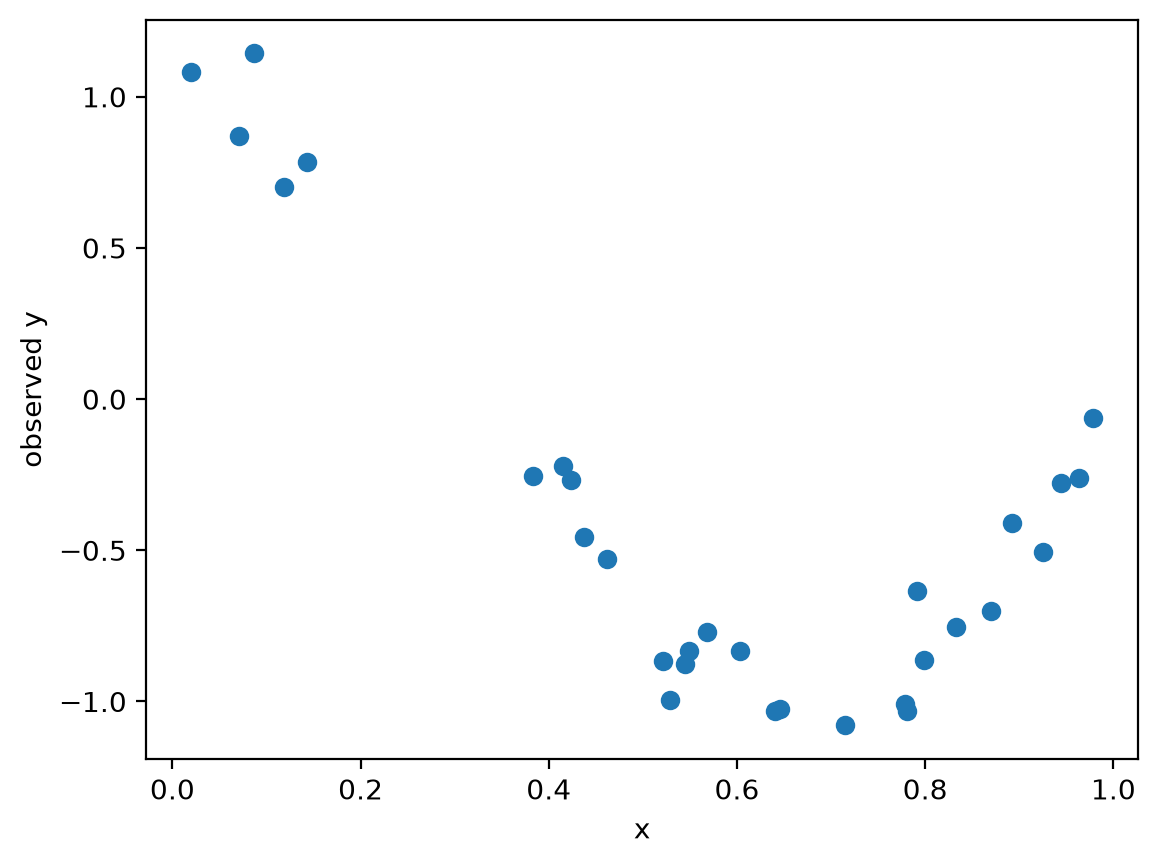

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina")  # 双倍像素内嵌输出，保留原图的显示尺寸
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))
y = np.cos(1.5 * np.pi * X) + np.random.randn(n_samples) * 0.1
print(X.shape, y.shape)
plt.scatter(X, y)
plt.xlabel("x"); plt.ylabel("observed y"); plt.show()


每个样本只有一个输入 x；标签 y 包含真实趋势和随机噪声。固定种子0保留原例数据。

<strong>停一下，检查：</strong> 重新运行只训练模型的单元，会产生新噪声吗？

<details><summary>查看解释</summary>

不会。只有重新执行数据生成代码才会赋值；本单元固定种子，重复运行仍得到同一批样本。

</details>


## 2｜为什么一列 x 能变成多项式？

先不拟合，打印前三个样本的 x、x²、x³、x⁴。


In [2]:
from sklearn.preprocessing import PolynomialFeatures
features = PolynomialFeatures(degree=4, include_bias=False)
X_column = X[:, None]  # (30,) → (30,1)，一行一个样本。
expanded = features.fit_transform(X_column)
print("输入与展开后的形状:", X_column.shape, expanded.shape)
print(np.round(expanded[:3], 4))


输入与展开后的形状: (30, 1) (30, 4)
[[0.0202 0.0004 0.     0.    ]
 [0.071  0.005  0.0004 0.    ]
 [0.0871 0.0076 0.0007 0.0001]]


模型是 y≈b+w₁x+w₂x²+w₃x³+w₄x⁴。对 x 可弯曲，对待估计系数仍是线性模型；常数列不重复添加。

<strong>停一下，检查：</strong> degree=1 时会生成几列？

<details><summary>查看解释</summary>

一列。include_bias=False 不生成全1列，截距由 LinearRegression 处理。

</details>


## 3｜先训练一个四阶模型

用 Pipeline 把特征展开与回归绑定。fit 学习参数，predict 使用参数。


In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
model4 = Pipeline([
    ("polynomial_features", PolynomialFeatures(degree=4, include_bias=False)),
    ("linear_regression", LinearRegression()),
])
model4.fit(X_column, y)
print("前三个预测:", model4.predict(X_column[:3]))
print("前三个观测:", y[:3])


前三个预测: [1.0334498  0.98279126 0.95194876]
前三个观测: [1.0819082  0.87027612 1.14386208]


预测与带噪声标签不同不一定是失败：模型应学习趋势，而不是强迫每个训练残差为0。

<strong>停一下，检查：</strong> 这里预测的是训练样本，能称独立测试吗？

<details><summary>查看解释</summary>

不能；这些样本刚参与 fit。训练拟合程度不能代替未见数据的表现。

</details>


## 4｜让未参与拟合的样本打分

均方误差 MSE=平均(预测−标签)²。先读十个折的误差，再看均值。


In [4]:
from sklearn.model_selection import cross_val_score
scores4 = cross_val_score(model4, X_column, y,
                         scoring="neg_mean_squared_error", cv=10)
print("每折 MSE:", -scores4)
print("均值、折间标准差:", -scores4.mean(), scores4.std())


每折 MSE: [0.25174939 0.04193604 0.02725282 0.02934695 0.00485939 0.00487645
 0.01858739 0.03843547 0.01218562 0.00285797]
均值、折间标准差: 0.04320874987231847 0.07077938529771499


sklearn 分数约定越大越好，所以返回负 MSE。cv=10 对回归默认不打乱；本例 X 已排序，每折覆盖相邻 x 区间。std 是折间波动，不是置信区间。

<strong>停一下，检查：</strong> cross_val_score 会直接用上一步已拟合参数预测所有折吗？

<details><summary>查看解释</summary>

不会；每折克隆并重新拟合完整 Pipeline，只用该折训练部分。

</details>


<strong>停一下，检查：</strong> 明明要的是 MSE，为什么参数写 neg_mean_squared_error，打印时又把负号加回来？

<details><summary>查看解释</summary>

sklearn 的评分接口统一约定「分数越大越好」，选型代码只需一律找最大分；MSE 是损失、越小越好，方向相反，于是被包装成 −MSE 交给统一接口。负号只是接口约定，不改变误差大小，所以读数时要自己翻回来：−scores4 是每折真实的 MSE，−scores4.mean() 是均值。若忘记翻负号，还会把「挑误差最小」误做成「挑分数最小」。

</details>


## 5｜只改变阶数，保持数据和评价不变

预测：1阶、15阶哪个会贴训练点更紧？先完成比较，再谈泛化。


In [5]:
degrees = [1, 4, 15]
models, cv_results = {}, {}
for degree in degrees:
    model = Pipeline([
        ("polynomial_features", PolynomialFeatures(degree=degree, include_bias=False)),
        ("linear_regression", LinearRegression()),
    ])
    model.fit(X_column, y)
    scores = cross_val_score(model, X_column, y, scoring="neg_mean_squared_error", cv=10)
    models[degree] = model
    cv_results[degree] = (-scores.mean(), scores.std())
    print(degree, "阶: CV MSE / std =", cv_results[degree])


1 阶: CV MSE / std = (np.float64(0.40772896250986834), np.float64(0.4254685884064715))
4 阶: CV MSE / std = (np.float64(0.04320874987231847), np.float64(0.07077938529771499))
15 阶: CV MSE / std = (np.float64(0.21959838160048156), np.float64(0.4199915281987455))


循环只重复刚学过的训练与评价，唯一变化是 degree。数值稳定性也随高阶特征改变；本例四阶较好，不是所有任务四阶最佳。

<strong>停一下，检查：</strong> 15阶训练曲线漂亮但 CV 误差高，应该如何描述？

<details><summary>查看解释</summary>

它在训练点附近的适配没有转化为稳定的折外预测，是过拟合/不稳定的证据；不能靠增加表达能力自动改善泛化。

</details>


<strong>停一下，检查：</strong> 1阶 0.41 与 15阶 0.22 相差近一倍，能断言 15阶稳定地优于 1阶吗？

<details><summary>查看解释</summary>

不能。本次划分中 15 阶的平均 MSE 低于 1 阶，但折间波动较大；仅凭均值和标准差，不能断言换一次划分后谁仍然更好。4 阶是本次比较中平均 CV MSE 最低的候选，因此按预定规则选它；折间标准差不是置信区间，也不能用均值差是否大于标准差来代替显著性检验。

</details>


## 6｜把数字对应到曲线

下面[绘图辅助文件](helpers/step_early.py)只接收已训练模型并画线，不隐藏训练。Model=模型，True function=无噪声函数，Samples=观测。


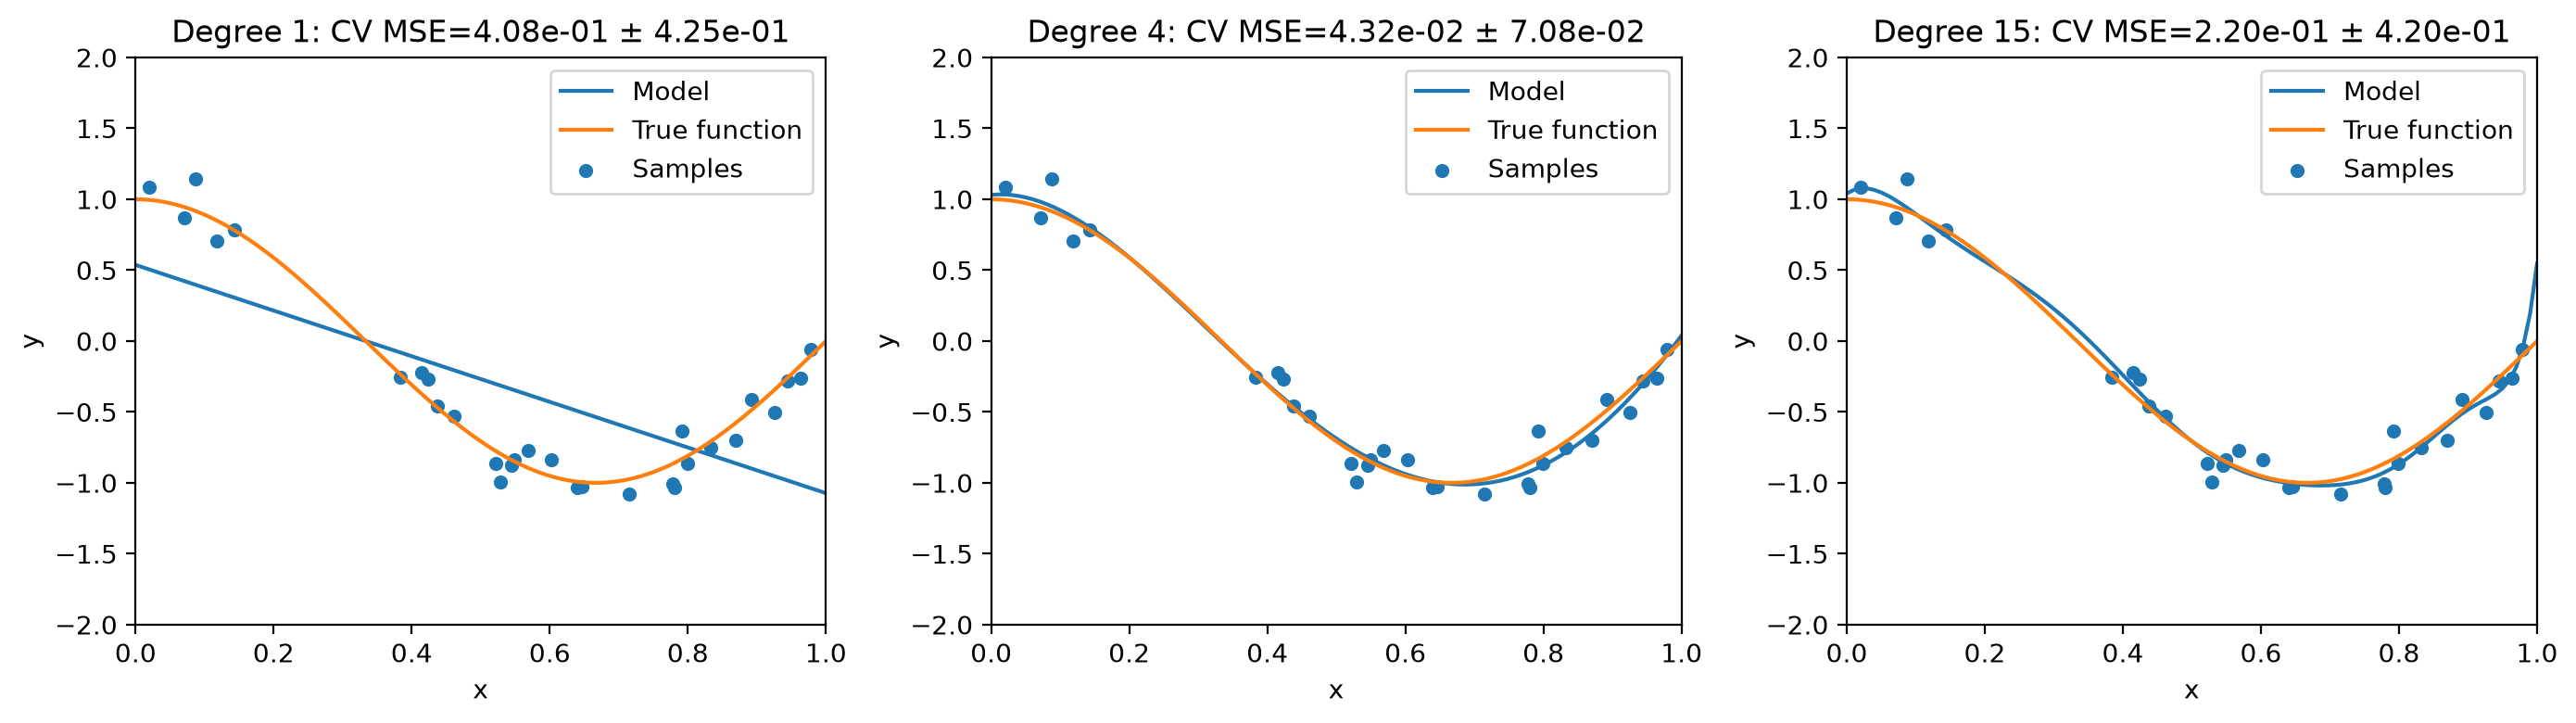

In [6]:
import sys
from pathlib import Path
from pathlib import Path
cwd = Path.cwd()
course_root = next((p for p in [cwd, *cwd.parents] if (p / "lessons").is_dir()), cwd)
notebook_dir = next((p for p in [cwd, course_root / "lessons/03-regression-gd/notebook"]
                     if (p / "03-regression-gd.ipynb").exists()), cwd)
sys.path.insert(0, str(notebook_dir))
from helpers.step_early import plot_polynomials
plot_polynomials(X, y, models, cv_results)


<strong>观察：</strong> y轴限制在−2到2，超范围预测可能被裁掉，要同时读误差。100个等距坐标仅用于画线，**不是独立测试集**。

<strong>迁移练习：</strong> 只改噪声0.1→0.3，先猜后重跑。提交三种阶数的误差与一句解释。

<details><summary>参考解释</summary>

更大噪声通常使误差上升，但每次实验必须报告实际结果；不要通过挑选较低分的CV划分来宣称泛化更好。

</details>


## 7｜残差诊断：模型没学到的部分在哪里？

对应课件 p21，接着 p20 的交叉验证（CV）。沿用同一批 30 个样本和 `models`，不重新生成数据。

**先猜**： 1 阶直线没学到余弦的弯曲，这部分会留在哪里？

残差统一定义为 **预测减真实**。先列出前三个样本，再画整批样本。


In [7]:
# [ref:residual-preview]
prediction = models[1].predict(X_column)
residual = prediction - y
print("前三行：x / 真实值 / 预测值 / 残差")
print(np.round(np.column_stack([X[:3], y[:3], prediction[:3], residual[:3]]), 4))


前三行：x / 真实值 / 预测值 / 残差
[[ 0.0202  1.0819  0.5041 -0.5778]
 [ 0.071   0.8703  0.4224 -0.4479]
 [ 0.0871  1.1439  0.3965 -0.7474]]


### 把残差画出来

两幅图共用纵轴尺度，横轴为训练样本 x，虚线为残差零线。与 p21 使用相同数据、模型和残差方向；课件额外加了分箱均值线，便于投影时看走势。


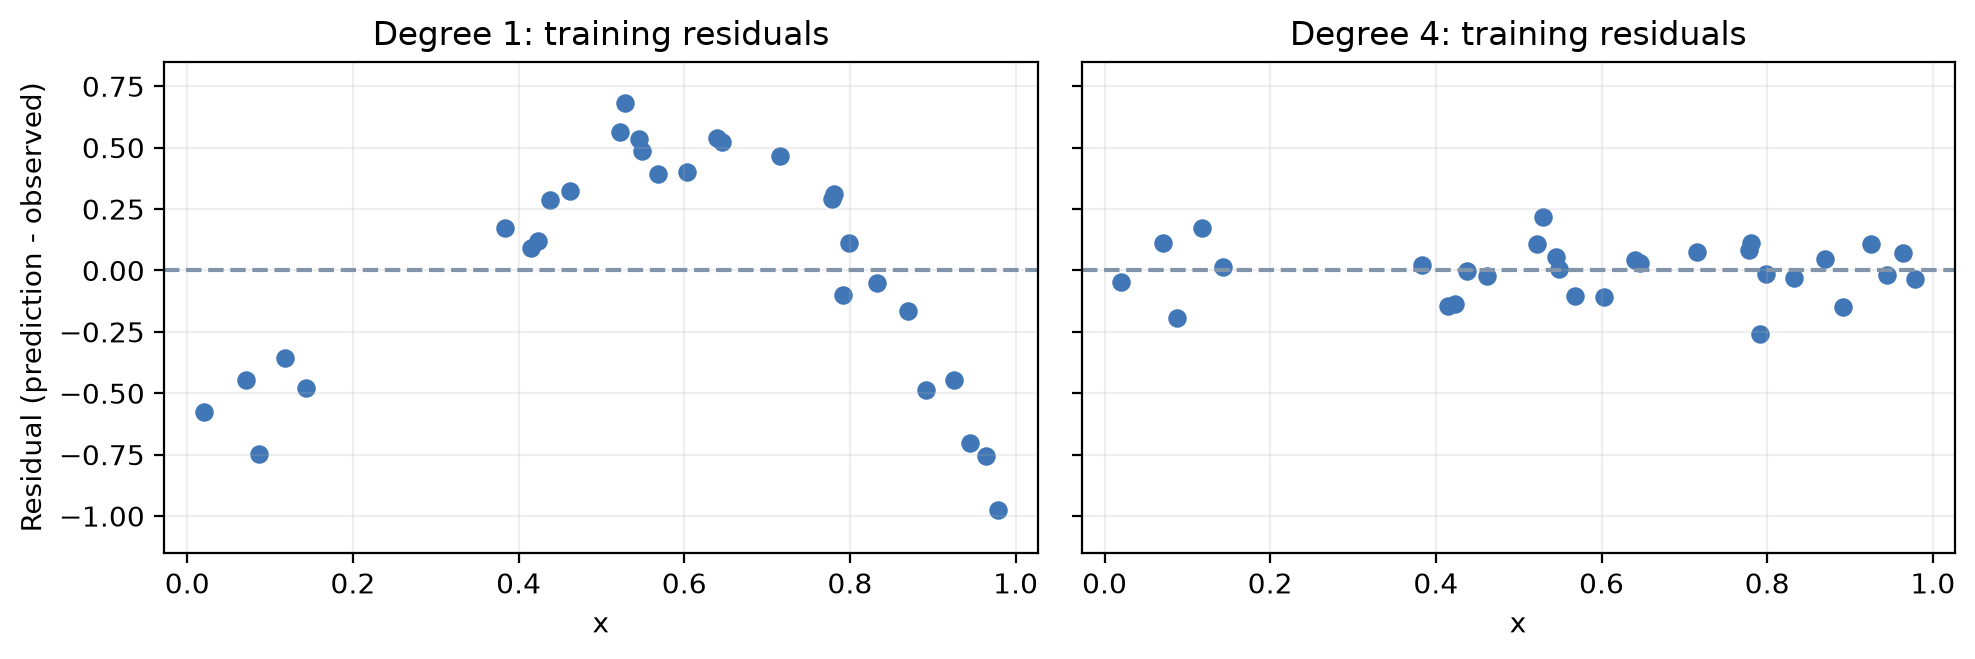

In [8]:
# [ref:residual-plot]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4), sharey=True)
for ax, degree in zip(axes, [1, 4]):
    residual = models[degree].predict(X_column) - y
    ax.scatter(X, residual, color="#4177b7", s=32)
    ax.axhline(0, color="#8194aa", linestyle="--")
    ax.set(title=f"Degree {degree}: training residuals", xlabel="x", ylim=(-1.15, 0.85))
    ax.grid(alpha=0.2)
axes[0].set_ylabel("Residual (prediction - observed)")
plt.tight_layout()
plt.show()


**观察**： 1 阶残差出现弯曲走势，提示直线遗漏了结构；4 阶残差的系统走势明显减弱。这里看的是训练残差，不能单凭“没有明显模式”判断泛化良好。

**再猜**： 15 阶的训练残差更小，能否推翻 p20 按 CV 选 4 阶的结果？把训练 MSE 与 CV MSE 放在一起看。


In [9]:
# [ref:residual-scores]
print("阶数 | 训练 MSE | 10 折 CV MSE")
for degree in [1, 4, 15]:
    residual = models[degree].predict(X_column) - y
    train_mse = np.mean(residual**2)
    print(f"{degree:>4} | {train_mse:.5f} | {cv_results[degree][0]:.5f}")


阶数 | 训练 MSE | 10 折 CV MSE
   1 | 0.22589 | 0.40773
   4 | 0.01156 | 0.04321
  15 | 0.01022 | 0.21960


<details><summary>检查答案</summary>

不能。15 阶训练 MSE 更低，但本次 CV MSE 高于 4 阶。残差图帮助找遗漏的结构，CV 则检查未参与当轮拟合的样本；两者回答不同问题。残差带模式是模型设定不足的线索，并非所有场景都能仅凭一张图断定欠拟合。

</details>


## 8｜外推警示：把预测范围拉长会怎样？

对应课件 p22。先用同一组余弦数据演示，再回到课件的房价例子。

**先猜**： 4 阶在本次 CV 中得分最好，是否保证它在训练范围外也准确？下面只扩大预测坐标，不重新拟合、不用范围外的信息选阶。


In [10]:
# [ref:extrapolation-values]
x_probe = np.array([-0.5, 0.5, 1.5])
print(f"训练 x 范围：[{X.min():.4f}, {X.max():.4f}]")
print("查询位置：", x_probe)
for degree in [1, 4, 15]:
    print(f"{degree:>2} 阶预测：", np.round(models[degree].predict(x_probe[:, None]), 3))
print("合成数据已知的无噪声函数：", np.round(np.cos(1.5 * np.pi * x_probe), 3))


训练 x 范围：[0.0202, 0.9786]
查询位置： [-0.5  0.5  1.5]
 1 阶预测： [ 1.341 -0.268 -1.877]
 4 阶预测： [-7.053 -0.687  4.563]
15 阶预测： [-1.7556000e+02 -7.0700000e-01  4.6290457e+04]
合成数据已知的无噪声函数： [-0.707 -0.707  0.707]


### 看范围内外的曲线

灰色带是实际训练 x 的最小值到最大值，外侧为外推区。三幅图共用 x、y 尺度；纵轴只显示 −3 到 3，超出部分被裁掉，**完整数值看上一格**。虚线是本合成实验已知的无噪声函数，现实任务通常没有这条参照线。


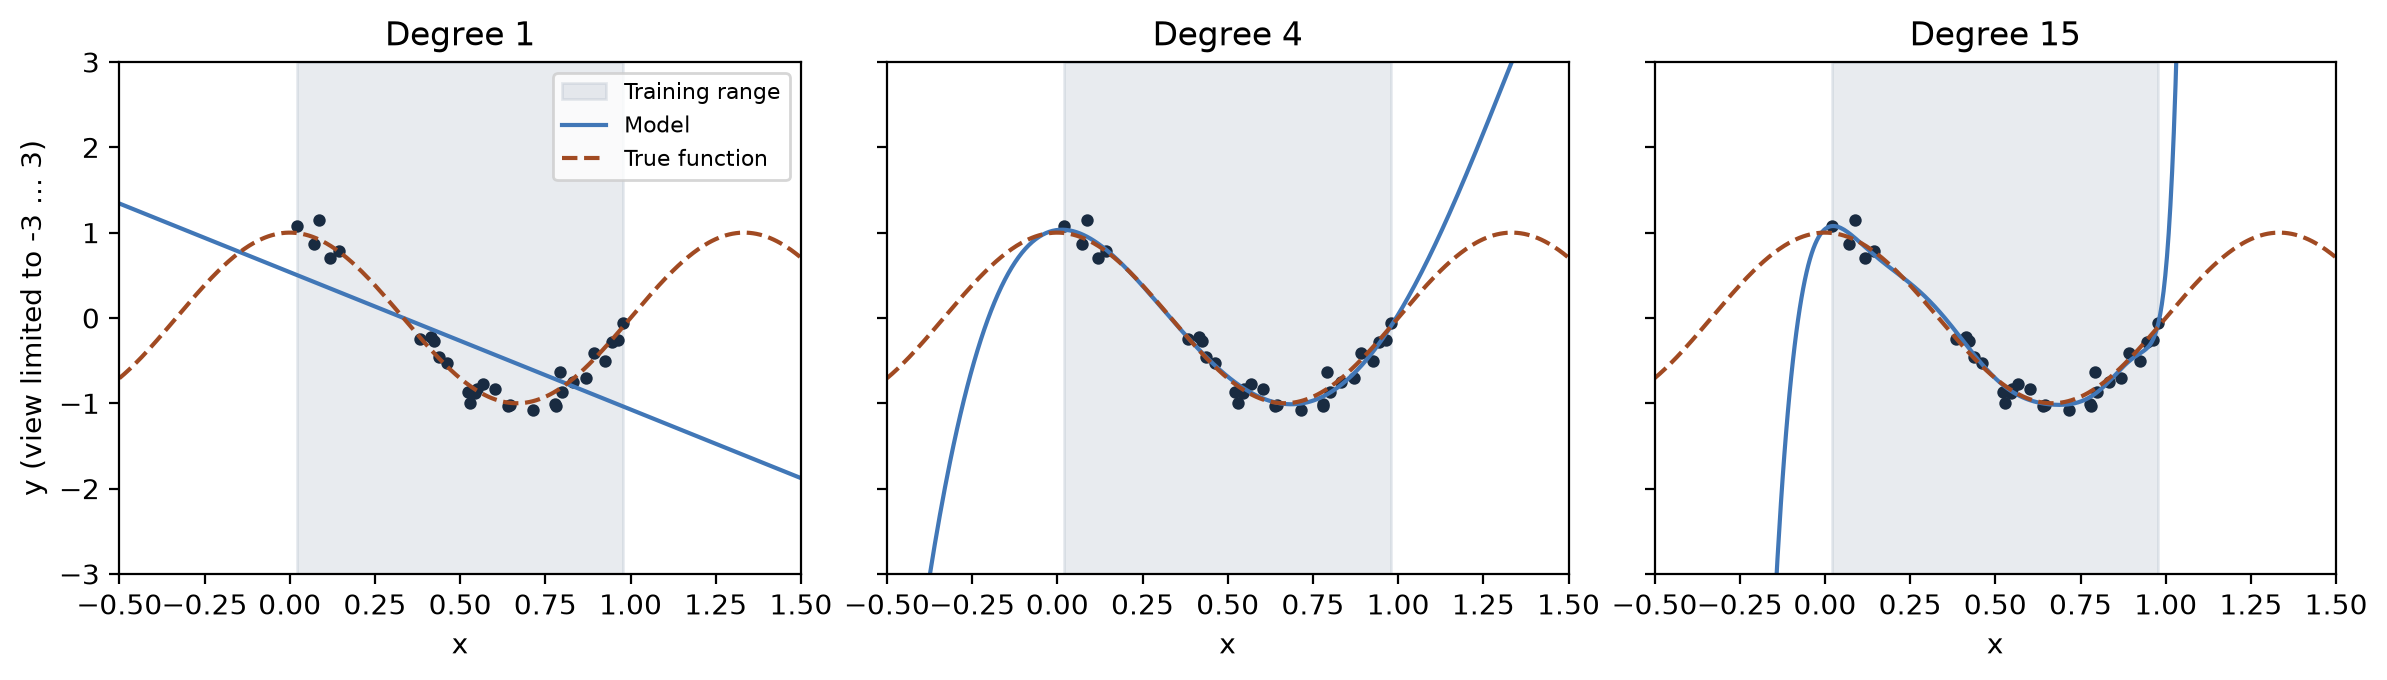

In [11]:
# [ref:extrapolation-plot]
x_wide = np.linspace(-0.5, 1.5, 400)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True, sharey=True)
for ax, degree in zip(axes, [1, 4, 15]):
    ax.axvspan(X.min(), X.max(), color="#8194aa", alpha=0.18, label="Training range")
    ax.plot(x_wide, models[degree].predict(x_wide[:, None]), color="#4177b7", label="Model")
    ax.plot(x_wide, np.cos(1.5*np.pi*x_wide), "--", color="#a14a22", label="True function")
    ax.scatter(X, y, color="#192b41", s=12)
    ax.set(title=f"Degree {degree}", xlabel="x", xlim=(-0.5, 1.5), ylim=(-3, 3))
axes[0].set_ylabel("y (view limited to -3 ... 3)")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 回到 p22：500 平米的房子能算，但有依据吗？

课件房价图是**合成示意**：24 个样本的面积从 30–150 ㎡均匀抽取，价格单位为万元；图中预设直线为 ŷ=3x+50，并非上面的余弦模型，也不是从这 24 点重新拟合得到的参数。下面只复核课件的手算读数，不把它称作模型评估。


In [12]:
# [ref:extrapolation-house]
area_query = np.array([100, 300, 500])
price_on_slide = 3 * area_query + 50
for area_value, price_value in zip(area_query, price_on_slide):
    region = "示意数据范围内" if 30 <= area_value <= 150 else "外推，无该范围成交记录"
    print(f"{area_value} ㎡ → {price_value} 万元；{region}")


100 ㎡ → 350 万元；示意数据范围内
300 ㎡ → 950 万元；外推，无该范围成交记录
500 ㎡ → 1550 万元；外推，无该范围成交记录


**检查题**： 500 ㎡算出 1550 万元，说明这个估价可信了吗？

<details><summary>检查答案</summary>

没有。1550 只是沿预设直线计算的结果，500 ㎡超出示意数据范围；需要该范围的数据和验证才能评价可信度。训练范围内也不是自动可信，还取决于模型、数据质量和验证结果。CV 的优势不能自动延伸到未覆盖的区域。

</details>

**课堂衔接**： p20 用 CV 比较候选模型 → p21 看训练残差中是否还有结构 → p22 检查新输入是否超出数据覆盖范围。
